# Programming Review for Data Science

This reading reviews the Python ideas that later course notebooks will use without stopping to reintroduce them. It is a review, not an entrance exam: if some syntax is new, run the examples in order, change one small piece at a time, and use the interpretation after each output.

By the end, you should be able to:

- reason about names, values, types, and basic collections;
- select values with zero-based indexing and slicing;
- distinguish functions from methods and import a package such as NumPy;
- recognize missing values and build a simple plot; and
- read a conditional, a loop, a list comprehension, and a `map` expression.

Course repositories are available through the [DS 3001 course website](https://github.com/sds3001).

## How to use this notebook

Run the code cells from top to bottom. A Jupyter kernel remembers names created by earlier cells, so running cells out of order can produce a state that the written sequence never intended. The stored outputs show what a clean top-to-bottom run should produce.

You need only basic algebra and a willingness to inspect examples. Readers coming from R, MATLAB, a spreadsheet, or no programming language at all may notice different punctuation, but the data-science questions—store a value, select observations, transform them, and repeat a task—are the same.

## A program is a sequence of instructions

In the procedural style common in data analysis, a script or notebook cell contains instructions that an interpreter runs in sequence. The instructions create objects, evaluate expressions, call functions, and choose or repeat blocks of work. Python also supports object-oriented programming, where data and related operations are organized into reusable classes. You do not need to design classes here, but you will use objects—such as strings, arrays, and data frames—that provide their own methods.

## Names are bound to values

**Question:** What does Python remember after `x = 5`?

The assignment statement binds the name `x` to the integer value `5`. The single equals sign assigns; it does not ask whether two values are equal.

In [1]:
x = 5
print(x)
print(2*x)   # Multiplication
print(x**2)  # Exponentiation

5
10
25


The output confirms that later expressions use the stored value. In real analysis, prefer descriptive names such as `first_regression` or `mean_income` over names such as `temp`. Python code commonly uses **snake case**, with lowercase words separated by underscores.

A `#` begins a **comment**: Python ignores the rest of that line. Comments are most useful when they explain a decision, assumption, or non-obvious step. They can also temporarily prevent one line from running.

In [2]:
x = 5  # Assign 5 to x
# x = 7  # This line is commented out
print(x)  # x is still 5

5


## A type says what a value can do

Every Python value has a **type**. Four types appear constantly in introductory data work:

- an **integer** (`int`) is a whole number such as `5`;
- a **floating-point number** (`float`) includes a decimal, such as `5.0`;
- a **Boolean** (`bool`) is either `True` or `False`; and
- a **string** (`str`) is text inside matching quotation marks, such as `"5"`.

Python also supports complex numbers, which are useful in some signal and time-series work but are not central to this review. In strings, a backslash begins an **escape sequence** such as `\n` for a newline; use `\\` when the text itself needs one backslash.

In [3]:
message = 'This is a string. \nThis is a new line. \nThis is a single backslash: \\.'
print(message)

This is a string. 
This is a new line. 
This is a single backslash: \.


## Booleans can participate in arithmetic

In numeric expressions, Python treats `True` like `1` and `False` like `0`. This is useful when a Boolean records whether an observation meets a condition: summing a Boolean array, for example, counts the `True` values. Use logical operators such as `and`, `or`, and `not` when the goal is logic rather than arithmetic; they state the intention more directly.

**Prediction:** Which products and sums below evaluate to zero?

In [4]:
x = True
y = False
z = True
w = False
print(x*y)
print(x+y-x*y)
print(x+z-x*z)
print(y+w-y*w)
print(2*x)

0
1
1
0
2


## Casting asks for a different type

Data that looks numeric may arrive as text. **Casting** (or type coercion) asks Python to construct one type from another: `float(x)`, `int(x)`, `str(x)`, or `bool(x)`. A cast can fail when the content is incompatible—for example, `float("$12,000")` needs cleaning before conversion.

In [5]:
x = '5'
print(type(x))
y = float(x)
print(type(y))
print(y**2)
print(bool('1'))

<class 'str'>
<class 'float'>
25.0
True


The string `'5'` and the number `5.0` contain related information but support different operations. Also notice that `bool('1')` is `True` because **any nonempty string** is truthy; Python is not interpreting the characters as a numeric one in that conversion.

## Collections encode relationships

A collection groups values, and its type expresses how they relate:

- a **list** is ordered and mutable, meaning its contents can change: `[3, 5, 7]`;
- a **tuple** is ordered and immutable after creation: `(3, 5, 7)`;
- a **set** holds unique, hashable values without a positional order: `{3, 5, 7}`; and
- a **dictionary** maps keys to values: `{"City": "Charlottesville"}`. Modern Python dictionaries preserve insertion order, but you normally retrieve their values by key rather than position.

Strings are ordered collections of characters. Choose a collection by asking whether order matters, whether contents must change, whether values must be unique, and whether a name should retrieve each value.

In [6]:
x = (3, 5, 7)
print(x)
# x[2] = 8  # A tuple does not allow item assignment
x = [3, 5, 7]
print(x)
x[2] = 8
print(x)

(3, 5, 7)
[3, 5, 7]
[3, 5, 8]


The tuple and list print similarly, but only the list accepts a replacement at position `2`. A commented line preserves the example of the invalid tuple assignment without interrupting a clean notebook run.

In [7]:
schools = {
    'University of Virginia',
    'Virginia Tech',
    'George Mason University',
    'College of William and Mary',
}
print(sorted(schools))  # Sort only to make the display deterministic
print(type(schools))
school = {'Name': 'University of Virginia', 'City': 'Charlottesville', 'State': 'VA'}
print(school)
print(school['City'])
print(type(school))

['College of William and Mary', 'George Mason University', 'University of Virginia', 'Virginia Tech']
<class 'set'>
{'Name': 'University of Virginia', 'City': 'Charlottesville', 'State': 'VA'}
Charlottesville
<class 'dict'>


The set's display is sorted only for readable, reproducible output; the set itself has no positional order. A set element must be hashable, so a list cannot be placed inside a set. The dictionary retrieves `Charlottesville` through the descriptive key `'City'`. Dictionaries are also a convenient way for a function to return several named results.

## Built-in collections do not perform vector arithmetic

**Prediction:** Does `x + x` add corresponding values when `x` is a tuple? Does `2*x` double each value?

In [8]:
x = (3, 2, 7)
print(x+x)  # Concatenation, not vector addition
print(2*x)  # Repetition, not scalar multiplication

(3, 2, 7, 3, 2, 7)
(3, 2, 7, 3, 2, 7)


## Indexes label positions from zero

An **index** identifies a position in an ordered object. Python starts at zero: index `0` is the first item, index `1` is the second, and so on. Negative indices work backward from the end, so `-1` is the last item.

**Question:** Which characters do the positive and negative indices select from `'Apple'`?

In [9]:
x = 'Apple'
print(x[1])
print(x[0])
print(x[-1])
print(x[-2])
print(x[-3])
print(x[-5])
# print(x[5])   # IndexError: there is no position 5
# print(x[-6])  # IndexError: this goes past the beginning

p
A
e
l
p
A


The output makes the boundary visible: a five-character string has valid nonnegative indices `0` through `4`. The same rule applies to lists and tuples.

In [10]:
x = (3, 2, 7, -1, 10)
print(x[0])  # First element
print(x[1])  # Second element
print(x[-1]) # Last element

3
2
10


## Functions take inputs and return outputs

A **function** packages a reusable operation. In `function_name(arguments)`, the values inside parentheses are inputs, and the function may return an output. Useful built-in functions include `type`, `len`, `sum`, `abs`, `round`, `max`, and `min`. Their valid behavior depends on the input type.

**Question:** How can we ask for the number of characters in a string?

In [11]:
x = 'Apple'
print(len(x))

5


## Define a function when a task repeats

Base Python has no built-in `mean(x)` function, but a mean needs only `sum` and `len`. A function definition begins with `def`; the indented block contains its work; and `return` sends a result back to the caller. A short string immediately inside the function is a **docstring** that explains its purpose.

**Question:** How can we write the calculation once and reuse it?

In [12]:
def mean(x):
    """Compute the mean of a list or tuple."""
    m = sum(x)/len(x)
    return m

x = (2, 3, -1, 7, 11)
print(mean(x))

4.4


## Methods are functions attached to objects

Objects can carry related data and operations. In `x.lower()`, `lower` is a **method** provided by the string object `x`. Attribute access with a dot can retrieve a method or another stored attribute. Compare `len(x)`, which passes `x` to a standalone function, with `x.lower()`, which asks the object to perform one of its methods.

In [13]:
x = 'Apple'
print(callable(x.format))  # x.format is a bound method
print(x.lower())
print('Apple'.upper())

True
apple
APPLE


`callable` confirms that `x.format` can be called. The two methods then return new lowercase and uppercase strings; strings themselves are immutable, so `x` remains `'Apple'` unless the returned value is assigned. Data frames and arrays use the same dot notation for many common transformations.

## Slices include the start, not the stop

A **slice** selects a consecutive range while preserving order. The notation `x[a:b]` starts at index `a` and stops **before** index `b`. `x[:b]` starts at zero, and `x[a:]` continues to the end. A stop beyond the end is allowed.

**Prediction:** How many values will each slice below contain?

In [14]:
x = (3, 2, 7, -1, 10)
print(x[0:3])
print(x[1:4])
print(x[2:])
print(x[:2])
print(x[2:100])

(3, 2, 7)
(2, 7, -1)
(7, -1, 10)
(3, 2)
(7, -1, 10)


The first slice contains indices `0`, `1`, and `2`, not index `3`. A useful mental model is a half-open interval: include the left boundary and exclude the right. Readers coming from a one-based language should take extra care not to translate positions directly into Python indices.

## Comparisons return Booleans

Use `==` to test equality; do not confuse it with assignment using `=`. Other comparison operators include `>`, `<`, `>=`, `<=`, and `!=`. For membership, use `in` or `not in`. A collection comparison such as `x == y` asks whether the two complete collections are equal; it does not ask whether one value appears inside the collection.

In [15]:
x = (2, 3, 5)
y = (2, 3, 5)
z = (-2, 4, 11)
print(x == y)
print(y == z)
print(x == 3)
print(5 == '5')
names = ['Abby', 'Amir', 'Alejandro']
print('Amir' in names)
print('Kyle' not in names)

True
False
False
False
True
True


The integer `5` and string `'5'` are not equal because type matters. The final two lines ask membership questions directly and print both answers rather than relying on Jupyter to display only the last expression in a cell.

## Modules and packages add tools

A **module** is a Python file containing reusable definitions. A **package** organizes modules so they can be imported together. An import such as `import numpy as np` gives the package a short, conventional alias. Common data-science packages include Pandas (`pd`) for tabular data, Matplotlib (`plt`) and Seaborn (`sns`) for plots, scikit-learn for machine learning, NumPy (`np`) for numerical arrays, statsmodels for statistical models, and Keras for neural networks.

Import only packages available in the environment; importing does not install them.

## Packages in action: a seeded sample

NumPy can generate a two-column numerical array, and Matplotlib can plot one column against the other. A random **seed** fixes the generator's starting state so this teaching example produces the same sample on each run.

**Question:** What does `sample[:, 0]` mean? Read it as “all rows from column zero.”

[[-1.74976547  0.3426804 ]
 [ 1.1530358  -0.25243604]
 [ 0.98132079  0.51421884]
 [ 0.22117967 -1.07004333]
 [-0.18949583  0.25500144]
 [-0.45802699  0.43516349]
 [-0.58359505  0.81684707]
 [ 0.67272081 -0.10441114]
 [-0.53128038  1.02973269]
 [-0.43813562 -1.11831825]]


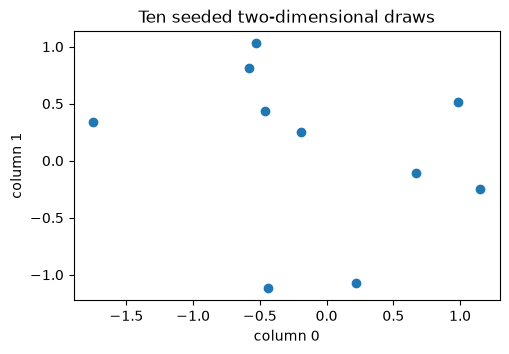

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)
sample = np.random.randn(10, 2)
print(sample)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(sample[:, 0], sample[:, 1])
ax.set(xlabel='column 0', ylabel='column 1', title='Ten seeded two-dimensional draws')
plt.show()

The printed array has ten rows and two columns. Each plotted point uses one row: its horizontal coordinate comes from column `0`, and its vertical coordinate comes from column `1`. Seeding makes the data reproducible; labels make the visual claim explicit.

## NumPy arrays support numerical operations

Python list multiplication repeats a list. A NumPy **array** instead applies ordinary arithmetic element by element and provides vector and matrix operations. Pandas builds many of its numerical behaviors on NumPy.

**Prediction:** How will `2*x` differ before and after converting the list to an array?

In [17]:
x = [3, 5, 7]
print(2*x)
y = np.array(x)
print(2*y)
z = np.array([-1, -2, -3])
print(y+z)
print(np.inner(y, z))
print(y/10.0)

[3, 5, 7, 3, 5, 7]
[ 6 10 14]
[2 3 4]
-34
[0.3 0.5 0.7]


The list repeats, while the array doubles element by element. Array addition combines corresponding positions, `np.inner` computes an inner product, and division acts on each element. This is the behavior most numerical analysis expects.

## NumPy provides methods and functions

Arrays provide methods such as `.min()`, `.max()`, `.mean()`, `.sum()`, `.sort()`, and `.round()`. NumPy also provides package-level functions. `np.where(condition)` returns indices where a condition is true; `np.linspace(a, b, n)` makes `n` equally spaced values including both endpoints; and `np.arange(a, b, step)` advances by `step` while excluding the stop.

In [18]:
x = np.linspace(2, 5, 10)
print(x, '\n')
print(np.where(x == 4.0), '\n')
y = np.arange(2.0, 5.0, 0.1)
print(y)

[2.         2.33333333 2.66666667 3.         3.33333333 3.66666667
 4.         4.33333333 4.66666667 5.        ] 

(array([6]),) 

[2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7
 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9]


The `linspace` grid contains exactly ten points, and the value `4.0` appears at zero-based index `6`. The `arange` grid stops at `4.9`; floating-point display may expose approximations in other calculations, so exact equality requires care when values were produced by arithmetic.

## Missing values require an explicit test

NumPy represents a missing numeric value with `np.nan` (“not a number”). Arithmetic involving `nan` usually returns `nan`. Missingness does not behave like ordinary equality, so use `np.isnan(x)` rather than `x == np.nan`.

In [19]:
x = np.nan
y = 1
print(1+x)
print(x*y)
print(x/y)
print(x == np.nan)
print(x == y)
print(np.isnan(x))

nan
nan
nan
False
False
True


The first three results propagate the missing value. Both equality comparisons are `False`, while `np.isnan(x)` correctly identifies the missing value. This distinction is essential when cleaning data.

## A plot turns arrays into a picture

A **scatterplot** places one point at each pair of horizontal and vertical values. To visualize a mathematical function, first make an `x` grid, compute the corresponding `y` values, and then plot the pairs.

**Question:** How does $y=x+6\sin(x)$ change between $-5$ and $5$?

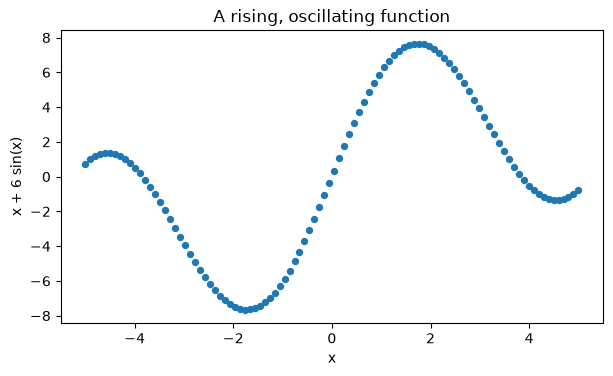

In [20]:
x = np.linspace(-5, 5, 100)
y = x + 6*np.sin(x)

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.scatter(x, y, s=18)
ax.set(xlabel='x', ylabel='x + 6 sin(x)', title='A rising, oscillating function')
plt.show()

The linear `x` term creates the overall upward movement, while `6*sin(x)` creates the repeating wave. The plot does not introduce new data; it makes a relationship already encoded in the two arrays easier to see.

## Control structures choose and repeat work

A **control structure** changes which instructions run. An `if` statement chooses a branch based on conditions. A `for` loop repeats an indented block for each value from an iterator. Python uses indentation to mark these blocks, so whitespace is part of the syntax.

## An `if` statement chooses one branch

**Question:** Which message should run for a negative value? Python tests conditions from top to bottom and runs the first matching branch.

In [21]:
x = -1

if x < 0:
    print('x is negative')
elif x == 0:
    print('x is zero')
else:
    print('x is positive')

print('x is: ', str(x))

x is negative
x is:  -1


Because `x < 0` is true, Python runs that block and skips the `elif` and `else` blocks. The final `print` is not indented under any branch, so it runs afterward in every case.

## A `for` loop repeats a block

Suppose a dataset has many auctions and you need the second-highest bid from each. A loop can visit each auction, apply the same procedure, and collect the results. A loop has an iteration variable, an iterable that supplies values, and an indented block to repeat.

The small example below converts every integer produced by `range(10)` to text. `range(10)` supplies values `0` through `9` without first constructing a ten-item list.

In [22]:
results = []

for index in range(10):
    results.append(str(index))

print(results)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


The common pattern is “start with an empty list, compute one result per item, and append.” A **list comprehension** expresses that pattern in one line. Use it when the expression remains easy to read; a clear loop is better than a compressed, confusing expression.

In [23]:
results = [str(index) for index in range(10)]
print(results)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


A third form, `map(function, iterable)`, asks Python to apply a function to each supplied value. In Python 3, `map` is **lazy**: it produces values as they are requested. Wrapping it in `list(...)` consumes the iterator and stores all results.

In [24]:
results = list(map(str, range(10)))
print(results)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## Readability first, vectorization when it matters

Python is popular partly because it is efficient for the person writing and reading the analysis. CPython, the implementation used in most notebooks, interprets Python instructions and has a global interpreter lock that limits some kinds of multithreaded Python execution. Numerical packages often move heavy work into compiled C, C++, Fortran, or Rust code.

That leads to a practical escalation path: first write clear correct code; then replace suitable element-by-element numerical loops with **vectorized** array operations; then use well-tested packages whose implementations are optimized. Specialized compilation or multiprocessing tools are available when measurement shows they are needed. List comprehensions and `map` are alternative expressions of iteration, not automatic speed guarantees.

## Vectorization example: compare results before speed

The earlier lecture timed two ways to sum one million seeded values. Exact timings change with hardware, load, and library versions, so this reading checks the more durable claim first: the explicit loop and NumPy operation should agree on the result.

In [25]:
N = 1_000_000
np.random.seed(101)
values = np.random.random_sample(N)

loop_total = 0.0
for value in values:
    loop_total += value

numpy_total = np.sum(values)
print('Same result:', np.isclose(loop_total, numpy_total))
print('Number of values:', len(values))

Same result: True
Number of values: 1000000


The two totals agree within a small floating-point tolerance. `np.sum` performs the bulk operation in optimized numerical code and is normally much faster than stepping through the array in Python, but a timing claim should be measured on the actual task and machine rather than copied as a universal ratio. The name `loop_total` also avoids overwriting Python's built-in `sum` function.

## A text example: three forms of iteration

The supporting file `src/news-summary.pkl` stores 2,224 news summaries. A **pickle** is a Python-specific serialized object; load only a trusted pickle because loading one can execute code. This file is checked into the course repository as a trusted teaching artifact.

The original output printed several complete summaries. Here we verify the dataset and show a compact property instead, keeping the reading focused.

In [26]:
from pathlib import Path
import pickle

data_path = Path('src') / 'news-summary.pkl'
with data_path.open('rb') as file:
    text = pickle.load(file)

print('Number of summaries:', len(text))
print('Words in the first summary:', len(text[0].split()))

Number of summaries: 2224
Words in the first summary: 192


Now compute a word count for every summary in three equivalent ways: an explicit loop, a list comprehension, and `map` with a small anonymous `lambda` function. The useful question at this scale is whether the methods agree and which one communicates the transformation most clearly.

In [27]:
loop_lengths = []
for summary in text:
    loop_lengths.append(len(summary.split()))

comprehension_lengths = [len(summary.split()) for summary in text]
map_lengths = list(map(lambda summary: len(summary.split()), text))

print('All three agree:', loop_lengths == comprehension_lengths == map_lengths)
print('First five word counts:', loop_lengths[:5])

All three agree: True
First five word counts: [192, 266, 225, 223, 185]


All three forms compute the same list. For this problem size, their timing differences are small and environment-dependent. The explicit loop makes each step easiest to inspect; the list comprehension is concise without hiding the operation; and `map` is natural when an existing named function already expresses the transformation.

## Carry this mental model forward

- Names refer to values; types and collections determine how those values behave.
- Indices and slices select values; functions and methods transform them.
- Packages add data-science tools such as arrays, missing-value checks, and plots.
- `if` chooses one path; `for` repeats; comprehensions and `map` express common iteration patterns.
- Clear, correct code comes first. Vectorize or optimize after the result is understood and performance is measured.

Next, use these reading skills in a data-wrangling notebook: identify the objects created by each cell, inspect their types and shapes, and predict what one line will return before you run it.